In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [39]:
data = pd.read_csv("books_data_cleaned.csv")

print(data.head())

                                   Title  Price  Rating
0                   A Light in the Attic  51.77       3
1                     Tipping the Velvet  53.74       1
2                             Soumission  50.10       1
3                          Sharp Objects  47.82       4
4  Sapiens: A Brief History of Humankind  54.23       5


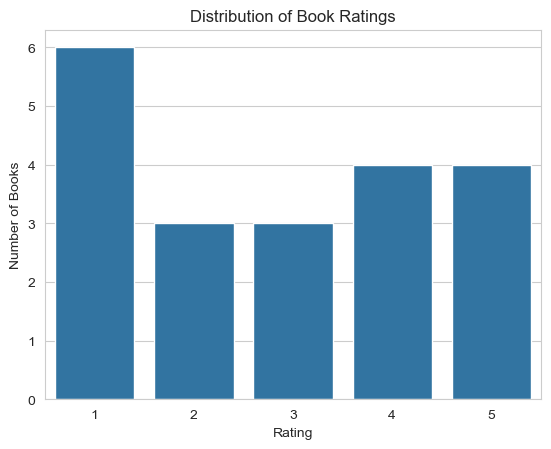

In [40]:
plt.figure()
sns.countplot(x="Rating", data=data)
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

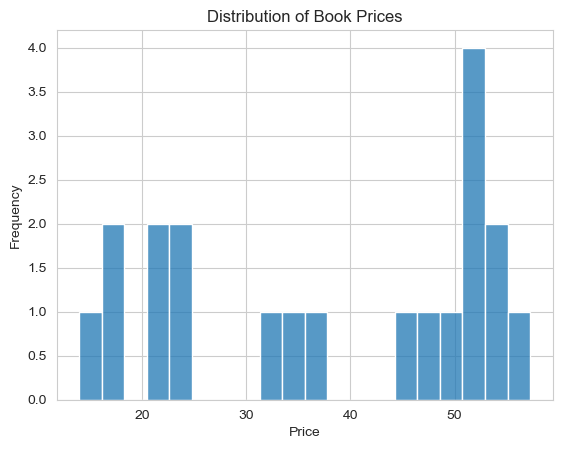

In [41]:
plt.figure()
sns.histplot(data["Price"], bins=20)
plt.title("Distribution of Book Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

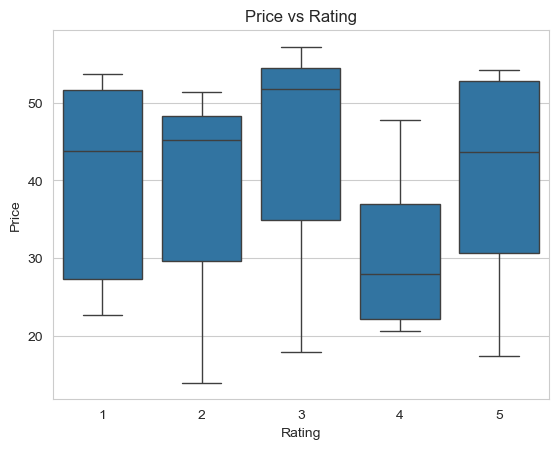

In [42]:
plt.figure()
sns.boxplot(x="Rating", y="Price", data=data)
plt.title("Price vs Rating")
plt.show()

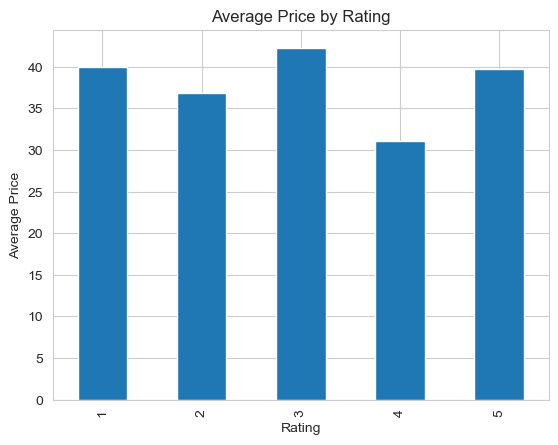

In [43]:
avg_price = data.groupby("Rating")["Price"].mean()

plt.figure()
avg_price.plot(kind="bar")
plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.show()

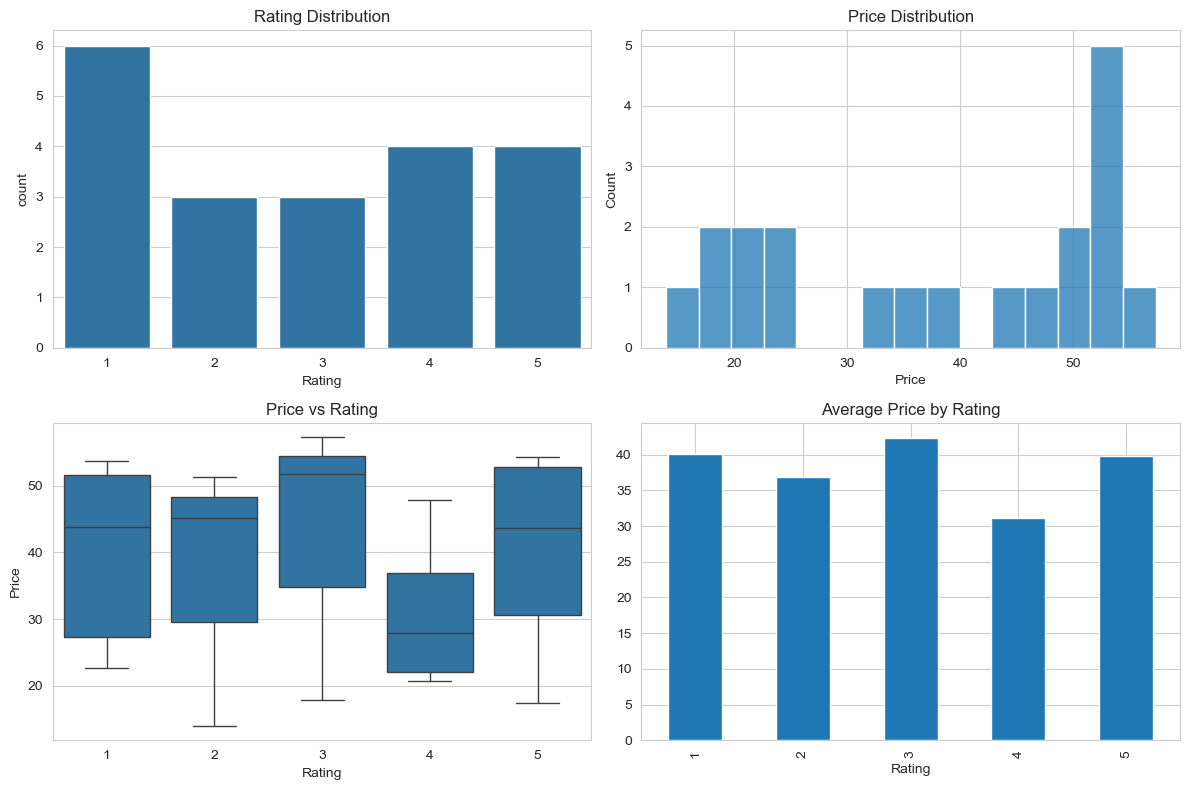

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.countplot(x="Rating", data=data, ax=axes[0,0])
axes[0,0].set_title("Rating Distribution")

sns.histplot(data["Price"], bins=15, ax=axes[0,1])
axes[0,1].set_title("Price Distribution")

sns.boxplot(x="Rating", y="Price", data=data, ax=axes[1,0])
axes[1,0].set_title("Price vs Rating")

avg_price = data.groupby("Rating")["Price"].mean()
avg_price.plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("Average Price by Rating")

plt.tight_layout()
plt.show()

In [47]:
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go

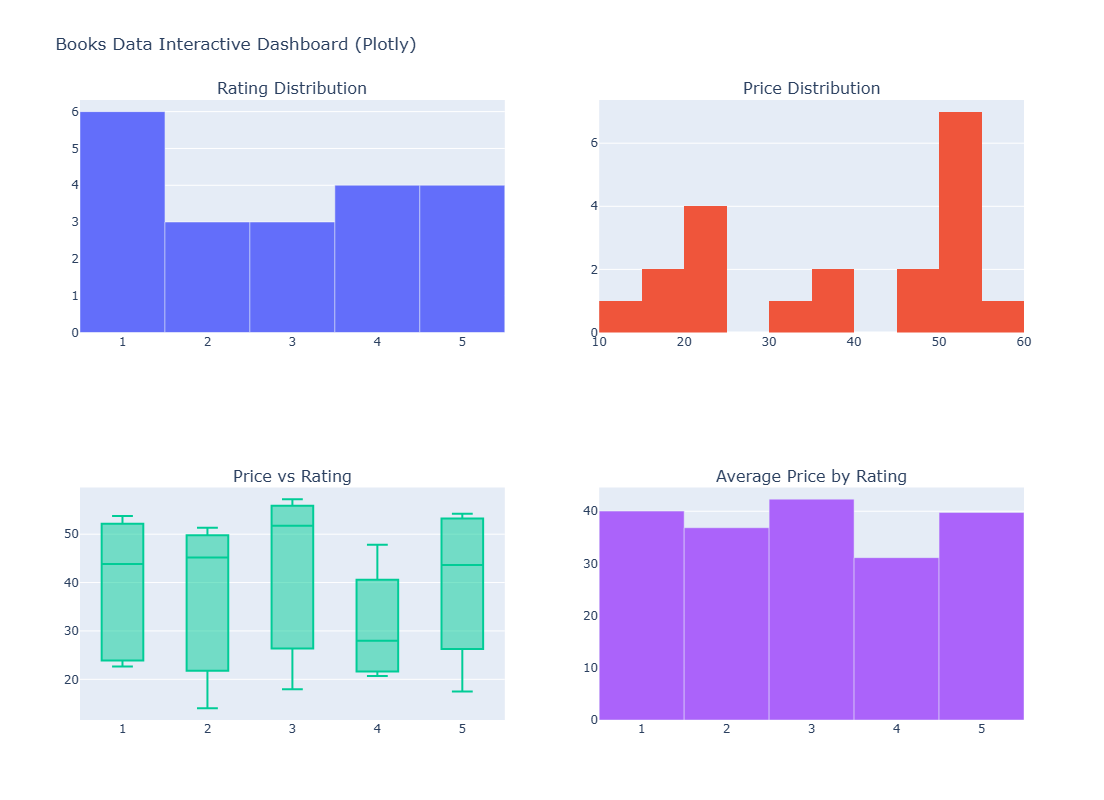

In [48]:
fig = sp.make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Rating Distribution",
        "Price Distribution",
        "Price vs Rating",
        "Average Price by Rating"
    )
)

rating_count = data["Rating"].value_counts().sort_index()
fig.add_trace(
    go.Bar(x=rating_count.index, y=rating_count.values, name="Ratings"),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(x=data["Price"], nbinsx=15, name="Price"),
    row=1, col=2
)

fig.add_trace(
    go.Box(x=data["Rating"], y=data["Price"], name="Price vs Rating"),
    row=2, col=1
)

avg_price = data.groupby("Rating")["Price"].mean()
fig.add_trace(
    go.Bar(x=avg_price.index, y=avg_price.values, name="Avg Price"),
    row=2, col=2
)

# Layout settings
fig.update_layout(
    height=800,
    width=1000,
    title_text="Books Data Interactive Dashboard (Plotly)",
    showlegend=False
)

fig.show()

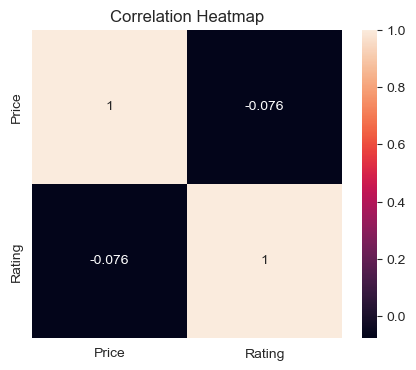

In [49]:
plt.figure(figsize=(5,4))
sns.heatmap(data[["Price", "Rating"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()